In [107]:
%pip install --q pandas scikit-learn scipy numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon

In [97]:
df_original = pd.read_csv(r'/workspaces/Projeto-Compara-o-Modelos-ML/Data/Student_performance_data _.csv')

display(df_original.head())

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [98]:
print(df_original.columns)

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='str')


In [99]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [100]:
df = df_original.copy()

df = df.drop(columns = 'StudentID')

In [101]:
df['GradeClass'] = df['GradeClass'].astype(int)
print(df['GradeClass'].value_counts())

GradeClass
4    1211
3     414
2     391
1     269
0     107
Name: count, dtype: int64


In [102]:
x = df.drop(columns = ['GPA', 'GradeClass'])

#Eixos de x dos algorimos de regressão
y_regressao = df['GPA']

#Eixos de y dos algorimos de classificação
y_classificacao = df['GradeClass']

# Algoritmos de classificação

### Acurácia entre Logistic Regression e Random Forest

In [103]:
print("Execução | Logistic Regression | Random Forest")
print("-" * 45)

run = 1

# Split primeiro
X_train, X_test, y_train, y_test = train_test_split(
    x, y_classificacao, test_size = 0.3
)

# Scaler aplicado ao treino
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelos
lr = LogisticRegression(max_iter = 5000)
rf = RandomForestClassifier(n_estimators = 100)

# Treinamento
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predições
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Avaliação
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"{run:^9} | {acc_lr:.4f}              | {acc_rf:.4f}")

Execução | Logistic Regression | Random Forest
---------------------------------------------


    1     | 0.7354              | 0.7047


### Vizualizações do Random Forest para o dataset

In [104]:
# Random Forest
X_train, X_test, y_train, y_test = train_test_split(
    x, y_classificacao, test_size=0.3, random_state=42
)

# Scaler aplicado ao treino
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nVariação apenas pelo random_state do modelo")
print("Seed | Random Forest Accuracy")
print("-" * 35)

for seed in range(10):
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=seed
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{seed:^4} | {acc:.4f}")


Variação apenas pelo random_state do modelo
Seed | Random Forest Accuracy
-----------------------------------
 0   | 0.6880
 1   | 0.6964
 2   | 0.7033
 3   | 0.6922
 4   | 0.7006
 5   | 0.6894
 6   | 0.6866
 7   | 0.6783
 8   | 0.7019
 9   | 0.6992


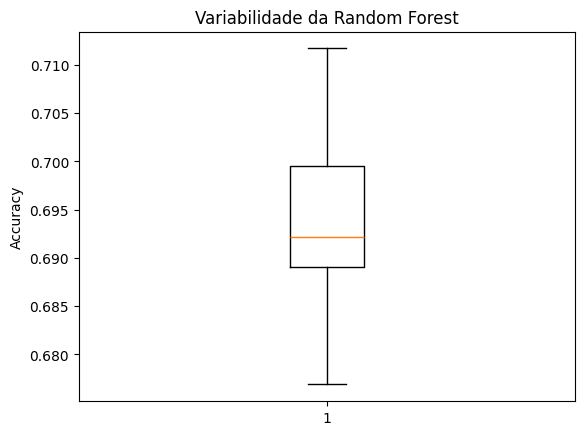

In [105]:
# Random Forest
results = []

for seed in range(20):
    rf = RandomForestClassifier(n_estimators = 100, random_state = seed)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    results.append(acc)

plt.boxplot(results)
plt.ylabel("Accuracy")
plt.title("Variabilidade da Random Forest")
plt.show()

### Vizualização do Logistic Regression para o dataset

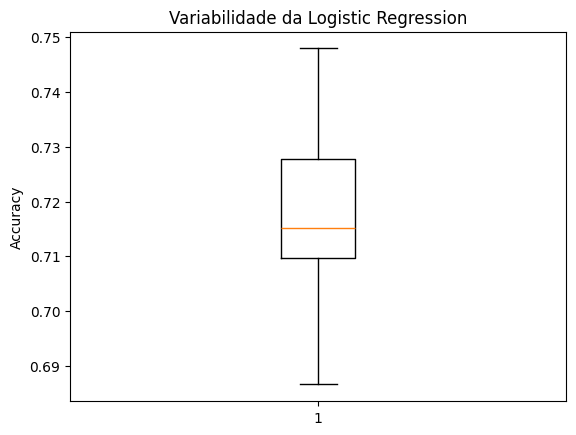

In [106]:
results = []

for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        x, y_classificacao, test_size = 0.3, random_state = seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    lr = LogisticRegression(max_iter = 5000)
    lr.fit(X_train, y_train)

    acc = accuracy_score(y_test, lr.predict(X_test))
    results.append(acc)

plt.boxplot(results)
plt.ylabel("Accuracy")
plt.title("Variabilidade da Logistic Regression")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# 1. Carregar base de dados
# =========================================================
data = load_wine()
X = data.data
y = data.target

print("Base:", data.DESCR.split("\n")[0])
print("Shape de X:", X.shape)
print("Número de classes:", len(np.unique(y)))

# =========================================================
# 2. Estratégia de validação cruzada
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================================================
# 3. Definir modelos e grades de hiperparâmetros
# =========================================================
models = {
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    },
    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        "params": {
            "model__C": [0.1, 1, 10, 100],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    },
    "RandomForest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5]
        }
    }
}

# =========================================================
# 4. Grid Search para cada modelo
# =========================================================
best_estimators = {}
best_params = {}
best_scores = {}

for name, config in models.items():
    print(f"\n========== {name} ==========")

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X, y)

    best_estimators[name] = grid.best_estimator_
    best_params[name] = grid.best_params_
    best_scores[name] = grid.best_score_

    print("Melhores hiperparâmetros:")
    print(grid.best_params_)
    print(f"Melhor acurácia média no GridSearchCV: {grid.best_score_:.4f}")

# =========================================================
# 5. Avaliação dos melhores modelos com cross validation
# =========================================================
cv_results = {}

for name, model in best_estimators.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    cv_results[name] = scores

# =========================================================
# 6. Organizar resultados em tabela
# =========================================================
results_df = pd.DataFrame(cv_results)
results_df.index = [f"Fold_{i+1}" for i in range(len(results_df))]

print("\n========== Resultados por fold ==========")
print(results_df)

summary_df = pd.DataFrame({
    "Média": results_df.mean(),
    "Desvio padrão": results_df.std()
}).sort_values(by="Média", ascending=False)

print("\n========== Resumo ==========")
print(summary_df)

# =========================================================
# 7. Teste estatístico global: Friedman
# =========================================================
stat_friedman, p_friedman = friedmanchisquare(
    results_df["KNN"],
    results_df["SVM"],
    results_df["RandomForest"]
)

print("\n========== Teste de Friedman ==========")
print(f"Estatística = {stat_friedman:.4f}")
print(f"p-valor     = {p_friedman:.4f}")

# =========================================================
# 8. Comparações par a par: Wilcoxon
# =========================================================
pairs = [("KNN", "SVM"), ("KNN", "RandomForest"), ("SVM", "RandomForest")]

print("\n========== Testes de Wilcoxon (par a par) ==========")
for a, b in pairs:
    stat, p = wilcoxon(results_df[a], results_df[b])
    print(f"{a} vs {b}: estatística = {stat:.4f}, p-valor = {p:.4f}")

NameError: name 'y' is not defined